# Simulation of satellite-detected hailstorms in the Australian tropics

In the Australian tropics, satellites and proxies often see indications of hail or hail-prone conditions, yet the actual occurrance of hail at the surface is uncertain given sparse observations. Here I use WRF to simulate hailstorms where satellite retrievals detected the presence of hail (aloft). The simulations are run using four microphysics schemes.

In [1]:
%cd ~/git/aus_tropics_hail/

/home/561/tr2908/git/aus_tropics_hail


In [2]:
import sys

sys.path.append('../xarray_parcel/')

import glob
import json
import logging
from importlib import reload
from pathlib import Path

import cartopy.crs as ccrs
import dask
import matplotlib as mpl
import matplotlib.pyplot as plt
import modules.nth_hail as nh
import modules.wrf_metadata as wm
import numpy as np
import pandas as pd
import xarray
from dask.distributed import Client


In [3]:
client = Client(n_workers=6, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 6,Total memory: 125.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45603,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36725,Total threads: 1
Dashboard: http://127.0.0.1:41093/status,Memory: 20.87 GiB
Nanny: tcp://127.0.0.1:39435,


## Environment

In [4]:
!module list

Currently Loaded Modulefiles:
 1) singularity                                         3) pbs  
 2) conda/analysis3-26.05(analysis3:esmvaltool:ilamb)  
>

In [5]:
!python --version

Python 3.12.13


## MY2 modification

WRF was stopping during runs using the MY2 microphysics scheme. When I asked Jason Milbrandt about this he wrote:

`Regarding MY2, that abort message has burned me many times.  It is a forced abort designed to give that warning message if the input temperature is unreasonable.  What is likely happening is that it is in a strong updraft and the intermediate adiabatic cooling due to ascent (after the dynamics but before the microphysics) results in a temporarily very cold temperature.  Several years ago I was running a squall line case in WRF with several other MP schemes; I put print statements in those other codes and similar temperatures appeared in those schemes also.  Ultimately (by the end of the time step) the saturation adjustment and diabetic heating returns the temperature back to sane values.  In short, it probably is not a problem in MY2 (at least that’s my guess).  The fix would be either to use a smaller time step or just comment out the STOP statement in the code.`

So, I have commented out these lines in WRF's `WRF/WRF/phys/module_mp_milbrandt2mom.F` file:

```
!-----                                                                                                                                                                  
!  if ( T(i,k)<173. .or. T(i,k)>323.) then                            !** DEBUG **                                                                                      
!     print*, '** STOPPING IN MICROPHYSICS: (Part 2, end) **'         !** DEBUG **                                                                                      
!     print*, '** i,k,T [K]: ',i,k,T(i,k)                             !** DEBUG **                                                                                      
!     stop                                                            !** DEBUG **                                                                                      
!  endif                                                              !** DEBUG **                                                                                      
!=====                                                                                  
```

## Settings

In [30]:
detecs_file = 'data/GPM_2014_2024_hail_events_P20_KIMB.nc'  # Bang & Cecil 2019 hail detections.
sims_dir = '/g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations/'  # Directory where simulations are held.
wrf_dir = '/g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/template/'  # Directory with compiled WRF.
namelist_dir = 'namelists/'  # Directory with template namelists.
prob_req = 0.5  # Hail probability required to include event.
hail_threshold = 20  # Threshold to count as a hail event.

## Setup

In [31]:
plt.show()  # Start the plotting engine.
plt.rcParams['font.size'] = 12  # Font size for plots.
plt.rcParams['axes.formatter.useoffset'] = False  # Don't use offsets in plots.
mpl.rcParams['pdf.fonttype'] = 42  # Use editable text in PDF in plots.
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)  # Suppress info messages when plotting.
_ = dask.config.set({'array.slicing.split_large_chunks': False})  # Allow for large dask chunks.
results = {}  # Dictionary for reportable results.

## Event selection

Events to simulate are selected from data provided by Sarah Bang, with locations and times of satellite-detected hailstorms. We look for "good" detections in northern Australia with a hail probability over 50%.

In [32]:
hail_detections = xarray.open_dataset(detecs_file).to_pandas()
hail_detections = hail_detections[hail_detections.DCflag == 1]  # Select storms not flagged for snow/surface features.
hail_detections = hail_detections[hail_detections.p_hail_BC2019 > prob_req]  # Select only probable detections.
hail_detections = hail_detections.reset_index(drop=True)
hail_detections['minute'] = np.floor(60 * (hail_detections.hour % 1))
hail_detections['hour'] = np.floor(hail_detections.hour)
print(f'The dataset contains {len(hail_detections)} hail detections.')
results['number_detections'] = len(hail_detections)
results['hail_threshold'] = hail_threshold

The dataset contains 61 hail detections.


We simulate the hour before the event, the hour of the event and the hour after the event, so each event has 3 hours of simulation time. The start time is shifted back 12 hours to give a 12 hour spin-up time. Total simulation time is then 15 hours per event.

In [33]:
hail_detections['event_time'] = (
    hail_detections.year.astype(int).astype(str).str.zfill(2)
    + '-'
    + hail_detections.month.astype(int).astype(str).str.zfill(2)
    + '-'
    + hail_detections.day.astype(int).astype(str).str.zfill(2)
    + ' '
    + hail_detections.hour.astype(int).astype(str).str.zfill(2)
    + ':'
    + hail_detections.minute.astype(int).astype(str)
)
hail_detections['event_time'] = pd.to_datetime(hail_detections.event_time, format='%Y-%m-%d %H:%M')
hail_detections['start_time'] = (hail_detections.event_time - np.timedelta64(13, 'h')).dt.floor('h')
hail_detections['end_time'] = (hail_detections.event_time + np.timedelta64(1, 'h')).dt.ceil('h')
hail_detections['start_time'] = hail_detections.start_time.dt.strftime('%Y-%m-%d_%H:%M:00')
hail_detections['end_time'] = hail_detections.end_time.dt.strftime('%Y-%m-%d_%H:%M:00')

In [10]:
hail_detections

,year,month,day,hour,latitude,longitude,p_hail_BC2019,DCflag,DCscore,minute,event_time,start_time,end_time
0,2014.0,12.0,4.0,11.0,-15.447296,130.743835,0.640928,1.0,0.999,32.0,2014-12-04 11:32:00,2014-12-03_22:00:00,2014-12-04_13:00:00
1,2014.0,12.0,5.0,10.0,-18.051325,139.738251,0.869298,1.0,0.998,41.0,2014-12-05 10:41:00,2014-12-04_21:00:00,2014-12-05_12:00:00
2,2014.0,12.0,6.0,11.0,-15.750792,126.886223,0.612656,1.0,0.999,20.0,2014-12-06 11:20:00,2014-12-05_22:00:00,2014-12-06_13:00:00
3,2014.0,12.0,7.0,10.0,-19.409584,129.686066,0.799357,1.0,0.795,28.0,2014-12-07 10:28:00,2014-12-06_21:00:00,2014-12-07_12:00:00
4,2014.0,12.0,14.0,9.0,-15.357926,125.715347,0.625072,1.0,0.999,1.0,2014-12-14 09:01:00,2014-12-13_20:00:00,2014-12-14_11:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2022.0,12.0,10.0,5.0,-16.433846,145.186386,0.527786,1.0,0.999,21.0,2022-12-10 05:21:00,2022-12-09_16:00:00,2022-12-10_07:00:00
57,2023.0,12.0,6.0,9.0,-14.814496,125.809784,0.698923,1.0,0.999,59.0,2023-12-06 09:59:00,2023-12-05_20:00:00,2023-12-06_11:00:00
58,2023.0,12.0,6.0,9.0,-16.602840,124.223366,0.909788,1.0,0.999,59.0,2023-12-06 09:59:00,2023-12-05_20:00:00,2023-12-06_11:00:00
59,2023.0,12.0,25.0,14.0,-15.710205,135.456711,0.584917,1.0,0.999,46.0,2023-12-25 14:46:00,2023-12-25_01:00:00,2023-12-25_16:00:00


Here is a map showing the locations of the hail detections we study here as red dots.

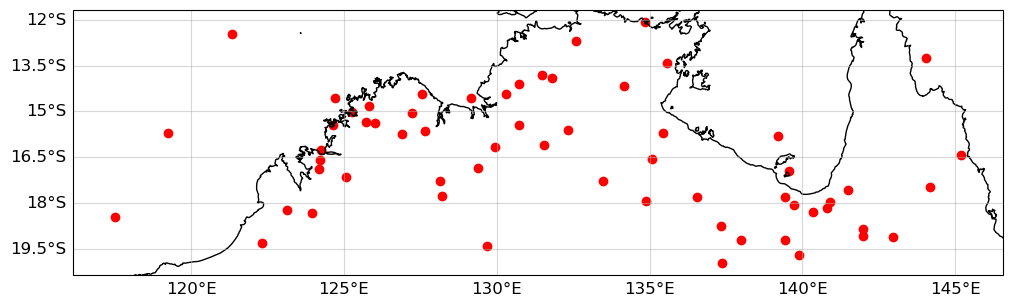

In [34]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 8))
ax.scatter(hail_detections.longitude, hail_detections.latitude, transform=ccrs.PlateCarree(), color='red')
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0.5)
gl.top_labels = gl.right_labels = False
ax.coastlines()
plt.show()

## Simulation computation

The following code can be run to create a directory for each simulation and set up all the namelist files to use the correct locations and times.

In [ ]:
# for _, row in hail_detections.iterrows():
#     nh.set_up_WRF(lat=row.latitude, lon=row.longitude, year=row.year, month=row.month, day=row.day,
#                   hour=row.hour, minute=row.minute, start_time=row.start_time, end_time=row.end_time,
#                   wrf_dir=wrf_dir, sims_dir=sims_dir, namelist_dir=namelist_dir)

To run WPS for each simulation:

```
cd /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations/
for i in lat*; do cd $i/WPS; echo `pwd`; qsub ~/git/aus_tropics_hail/scripts/run_WPS.sh; cd ../../; done
```

Once WPS has run on all, then run WRF:

```
cd /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/aus_tropics_hail/scripts/run_WRF.sh; cd ../../../; done
```

To remove spin-up times:

```
for i in lat*/WRF/*; do cd $i; echo $i; ls -1 wrfout_d02* | sort | head -n -3 | xargs rm -f; cd ../../../; done
for i in lat*/WRF/*; do cd $i; echo $i; ls -1 wrfout_d03* | sort | head -n -3 | xargs rm -f; cd ../../../; done
```

It's also safe to remove all wrfout_d01 files to save space.

After WRF has finished, then run two scripts to calculate basic properties for the last three files (leaving out spin up):

```
cd /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/aus_tropics_hail/scripts/process_WRF_basic.sh; cd ../../../; done
```

Run a script to calculate convective properties:

```
cd /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/aus_tropics_hail/scripts/process_WRF_conv.sh; cd ../../../; done
```

And finally run a script to interpolate vertical data to pressure levels:

```
cd /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*; do cd $i; echo `pwd`; qsub ~/git/aus_tropics_hail/scripts/interpolate_to_hPa_levels.sh; cd ../../../; done
```

To clean out symlinks to reduce inode usage:

```
cd /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations/
bash ~/git/aus_tropics_hail/scripts/clean_runs.sh
```

Or

```
for i in lat*/WRF/*; do find $i -maxdepth 1 -type l -exec rm {} +; done
```

To remove the "missing_values" attribute that caused xarray warnings from `basic_*.nc files`, I ran:

```
cd /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations/
for i in lat*/WRF/*/basic*.nc; do echo $i; ncatted -O -a missing_value,pressure,d,, $i; done
```

## Simulation details

Here are details of the simulation setup, which is simply moved and placed over each hail detection. Three different microphysics schemes are used (NSSL, P3-3M, and MY2). (Wrfout data may be archived in which case these lines are commented out). For the finer domain:

In [35]:
row = hail_detections.iloc[1,]
dr = nh.sim_directory(
    lat=row.latitude,
    lon=row.longitude,
    year=row.year,
    month=row.month,
    day=row.day,
    hour=row.hour,
    minute=row.minute,
    sims_dir=sims_dir,
)
wm.analyse_wrfinput(glob.glob(f'{dr}/WRF/NSSL/wrfout_d03*')[0])

Sea surface temperature (SST):			0.0 K
Surface skin temperature (TSK):			296.79178 K
Soil temperature at lower boundary (TMN):	299.27527 K
Horizontal grid spacing (DX):			1000.0 m
Horizontal (S-N) grid spacing (DY):		1000.0 m
Horizontal (W-E) domain size:			120 mass points
Horizontal (S-N) domain size:			120 mass points
Vertical domain size:				79 mass points
Maximum geopotential height (model-top):	20597.3 m
Min, mean, max vertical dist. between mass pts:	53.7, 260.4, 354.8 m
Model-top pressure:				5000.0 Pa
Physics schemes:
	Microphysics:				18 (NSSL 2-moment with CCN prediction)
	Radiation (longwave):			4 (RRTMG)
	Radiation (shortwave):			4 (RRTMG)
	Surface layer:				1 (Revised MM5 Monin-Obukhov)
	Land-surface:				4 (Noah-MP)
	PBL:					1 (YSU)
	Cumulus:				0 (No cumulus parameterisation)
Turbulence options:
	Diffusion (diff_opt):			2 (Full diffusion)
	Eddy coefficient (km_opt):		4 (2D (horiz) Smagorinsky)


And for the coarser middle domain:

In [ ]:
wm.analyse_wrfinput(glob.glob(f'{dr}/WRF/NSSL/wrfout_d02*')[0])

## Read data

In [129]:
spatial_means_1km, spatial_maxes_1km, spatial_mins_1km, spatial_counts_1km = nh.read_data(
    hail_detections=hail_detections,
    sims_dir=sims_dir,
    hail_threshold=hail_threshold,
    domain='d03',
)

In [130]:
spatial_means_3km, spatial_maxes_3km, spatial_mins_3km, spatial_counts_3km = nh.read_data(
    hail_detections=hail_detections,
    sims_dir=sims_dir,
    hail_threshold=hail_threshold,
    domain='d02',
    subset_to_inner=True,
)

In [131]:
spatial_means = xarray.concat([spatial_means_1km, spatial_means_3km], dim='domain')
spatial_mins = xarray.concat([spatial_mins_1km, spatial_mins_3km], dim='domain')
spatial_maxes = xarray.concat([spatial_maxes_1km, spatial_maxes_3km], dim='domain')
spatial_counts = xarray.concat([spatial_counts_1km, spatial_counts_3km], dim='domain')

## Number of hail vs no-hail simulations

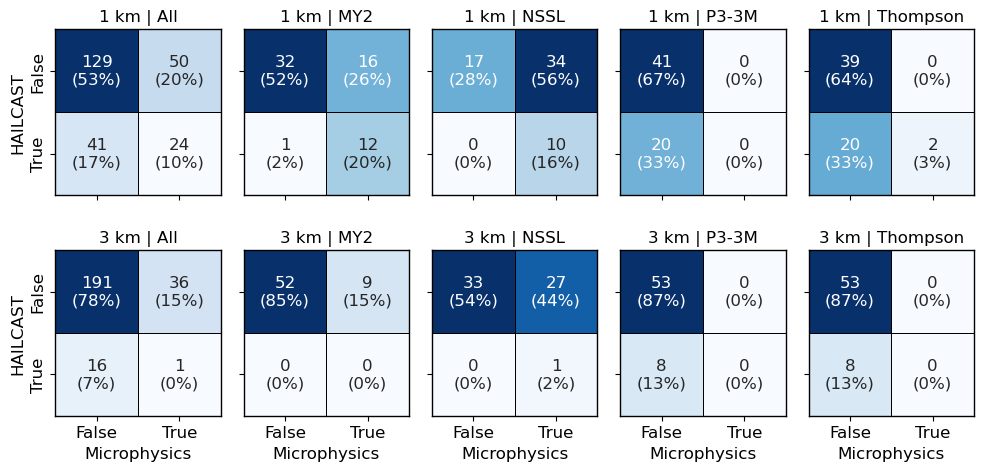

In [132]:
con = nh.confusion_matrix(dat=spatial_means, file='paper/figures/conf_matrix.pdf', figsize=(10, 5))

In [133]:
results['event_contained_hail_hailcast'] = int(con.query("domain == '1 km' and scheme == 'All' and hailcast == True")['n'].sum())
results['event_contained_hail_micro'] = int(con.query("domain == '1 km' and scheme == 'All' and micro == True")['n'].sum())

## Hailcast vs microphysics hail sizes

In [136]:
reload(nh)

<module 'modules.nth_hail' from '/home/561/tr2908/git/aus_tropics_hail/modules/nth_hail.py'>

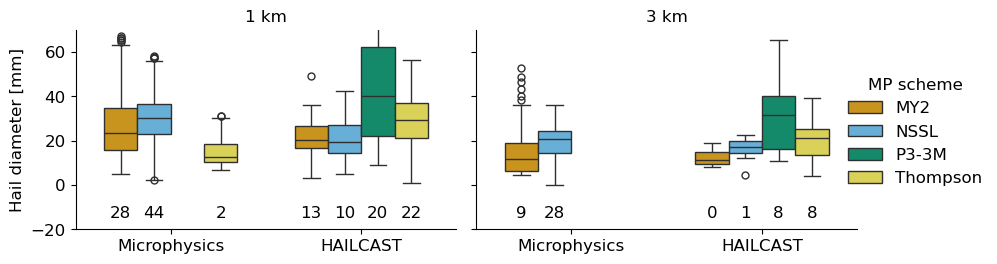

In [139]:
_, _ = nh.plot_surface_hailsizes(
    spatial_maxes=spatial_maxes,
    file='paper/figures/hailsizes.pdf',
    max_y=70,
)

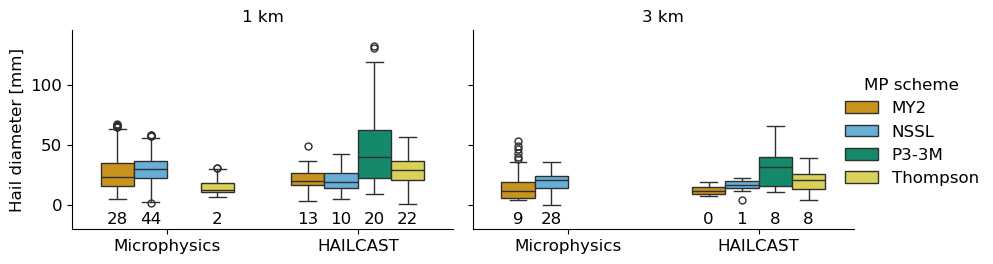

In [140]:
(results['hailcast_damaging_cases'], results['mp_damaging_cases']) = nh.plot_surface_hailsizes(
    spatial_maxes=spatial_maxes,
    file='paper/supplementary/hailsizes_full.pdf',
)

# Subset to only 1 km grid spacing for rest of analyses

In [141]:
spatial_means = spatial_means.sel(domain='1 km')
spatial_maxes = spatial_maxes.sel(domain='1 km')
spatial_mins = spatial_mins.sel(domain='1 km')
spatial_counts = spatial_counts.sel(domain='1 km')

## Locations of damaging surface hail

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0, 0.5, '% events containing damaging surface hail')

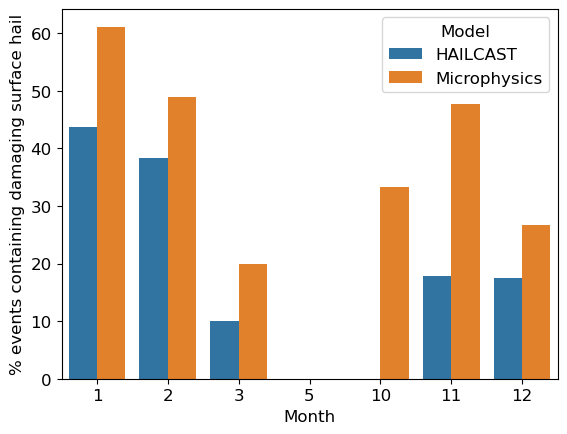

In [142]:
import seaborn as sns

sp = spatial_means.copy()
sp['event_includes_hail_micro'] = sp['event_includes_hail_micro'].where(~(sp.mp_scheme=='P3-3M'))

months = (sp.groupby(spatial_means.time.dt.month).mean()[['event_includes_hail_hailcast', 'event_includes_hail_micro']] * 100).to_dataframe()
months = months.rename(columns={'event_includes_hail_hailcast': 'HAILCAST', 'event_includes_hail_micro': 'Microphysics'}).drop(columns='domain')
#sns.barplot(months, x='month', y='value')
months = months.reset_index().melt(
    id_vars='month',
    value_vars=['HAILCAST', 'Microphysics'],
    var_name='Model',
    value_name='Value',
)
sns.barplot(data=months, x='month', y='Value', hue='Model')

plt.xlabel('Month')
plt.ylabel('% events containing damaging surface hail')

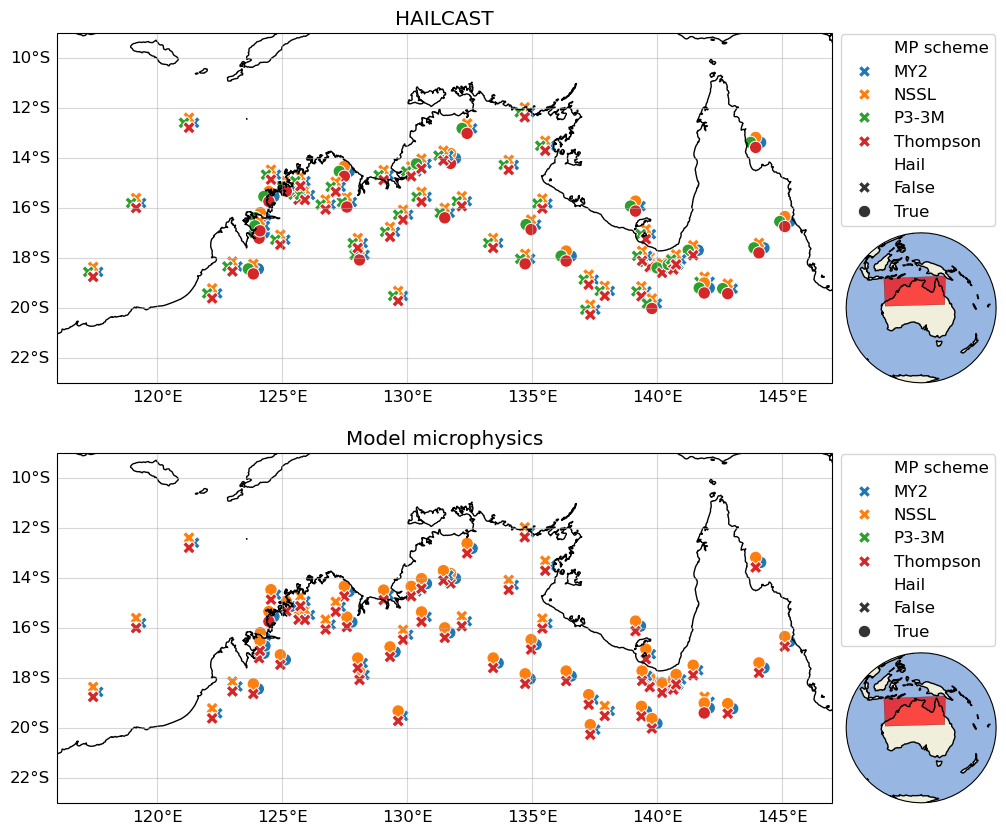

In [143]:
nh.plot_hail_simulations(dat=spatial_means, ylim=(-23, -9), xlim=(116, 147), figsize=(10, 10), file='paper/figures/sims_map.pdf')

## Environmental differences

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


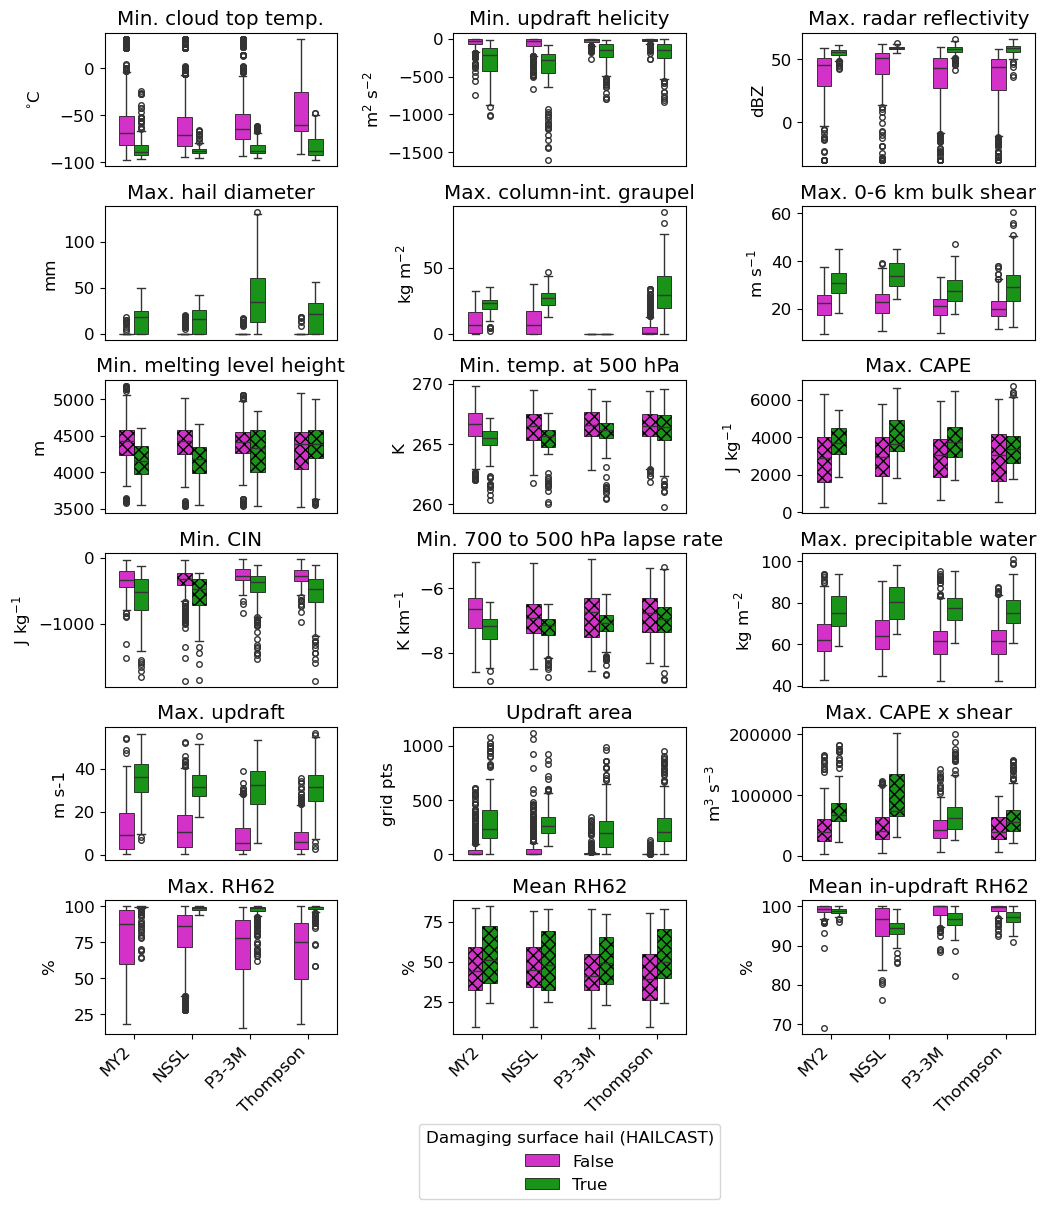

In [144]:
nh.plot_extrema(
    mins=spatial_mins,
    maxes=spatial_maxes,
    counts=spatial_counts,
    means=spatial_means,
    hail_indicator='HAILCAST',
    file='paper/figures/mins_maxes_hailcast.pdf',
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


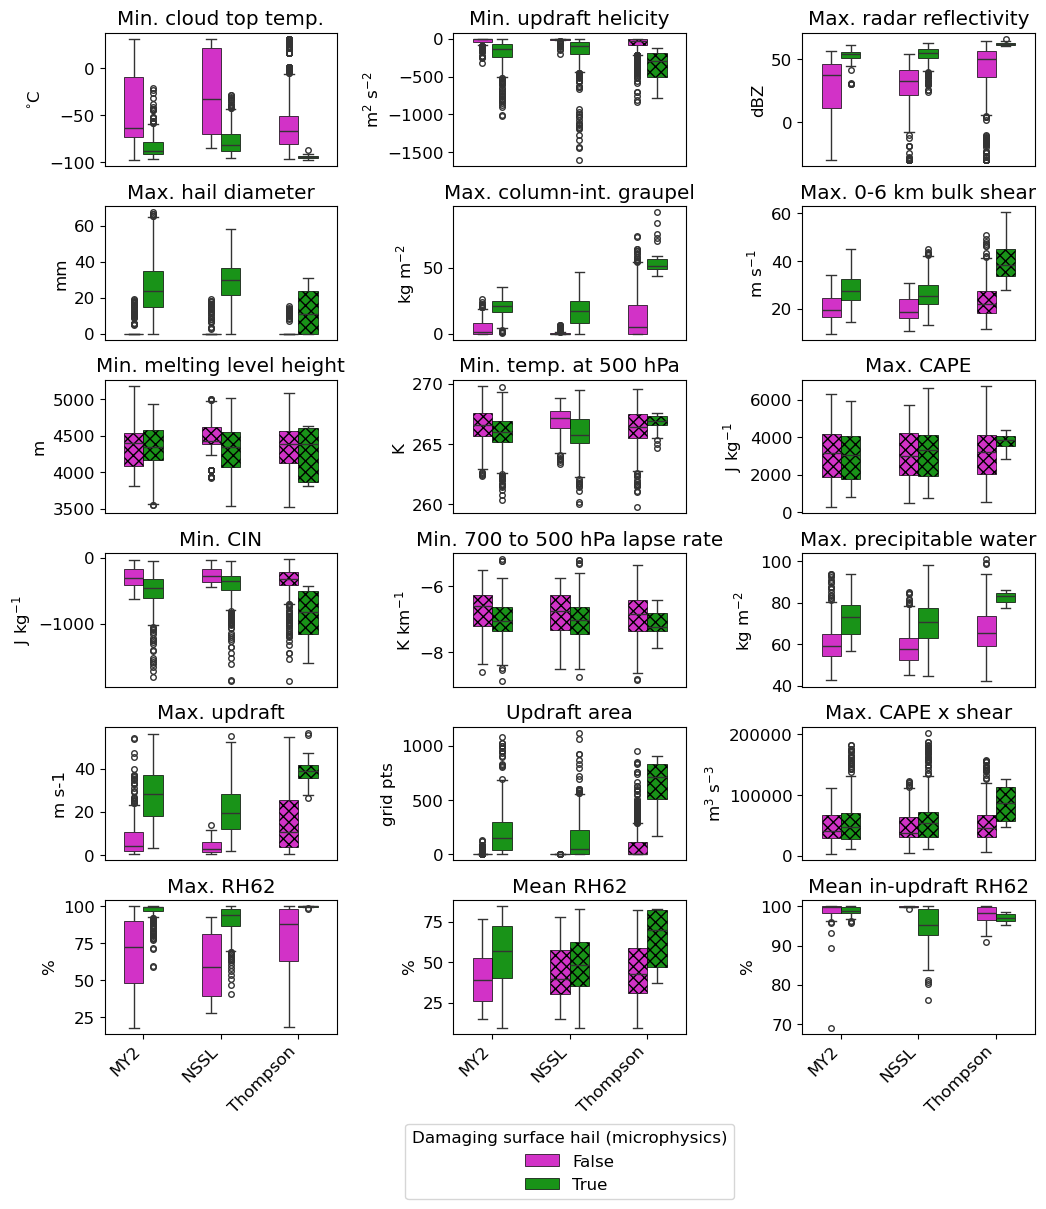

In [145]:
nh.plot_extrema(
    mins=spatial_mins,
    maxes=spatial_maxes,
    counts=spatial_counts,
    means=spatial_means,
    hail_indicator='microphysics',
    file='paper/supplementary/mins_maxes_microphysics.pdf',
)

## Mean skew-T plots by microphysics scheme for hour of hail detection

In [195]:
reload(nh)

<module 'modules.nth_hail' from '/home/561/tr2908/git/aus_tropics_hail/modules/nth_hail.py'>

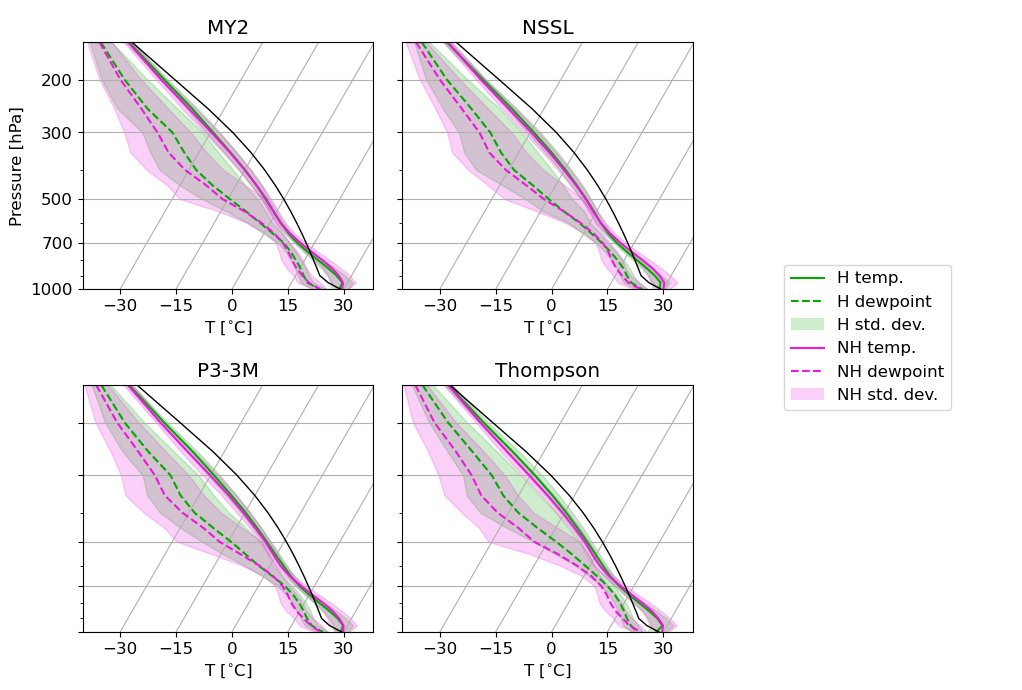

In [196]:
nh.skew_T_comp(dat=spatial_means, figsize=(12, 8.5), file='paper/figures/skewT_comp_hailcast.pdf')

In [ ]:
nh.skew_T_comp(dat=spatial_means, figsize=(12, 3), file='paper/supplementary/skewT_comp_micro.pdf', hail_indicator='microphysics')

## Mean vertical profiles of hydrometeor mixing ratios for hour of hail detection

In [ ]:
reload(nh)
nh.comp_profiles(
    dat=spatial_means,
    factor=1000,
    variables=['qcloud_at_p', 'qrain_at_p', 'qice_at_p', 'qgraup_at_p', 'qhail_at_p'],
    varnames={
        'qcloud_at_p': 'Cloud [g kg$^{-1}$]',
        'qrain_at_p': 'Rain [g kg$^{-1}$]',
        'qice_at_p': 'Ice [g kg$^{-1}$]',
        'qgraup_at_p': 'Graupel [g kg$^{-1}$]',
        'qhail_at_p': 'Hail [g kg$^{-1}$]',
    },
    figsize=(12, 11),
    file='paper/figures/hydromets_hailcast.pdf',
)

In [ ]:
nh.comp_profiles(
    dat=spatial_means,
    factor=1000,
    variables=['qcloud_at_p', 'qrain_at_p', 'qice_at_p', 'qgraup_at_p', 'qhail_at_p'],
    varnames={
        'qcloud_at_p': 'Cloud [g kg$^{-1}$]',
        'qrain_at_p': 'Rain [g kg$^{-1}$]',
        'qice_at_p': 'Ice [g kg$^{-1}$]',
        'qgraup_at_p': 'Graupel [g kg$^{-1}$]',
        'qhail_at_p': 'Hail [g kg$^{-1}$]',
    },
    figsize=(12, 8),
    leg_pos=-0.12,
    file='paper/supplementary/hydromets_micro.pdf',
    hail_indicator='microphysics',
)

## Mean vertical profiles of humidity, wind, and radar reflectivity for hour of hail detection 

In [ ]:
nh.comp_profiles(
    dat=spatial_means,
    variables=['rh_at_p', 'u_at_p', 'v_at_p', 'w_at_p', 'dbz_at_p'],
    varnames={
        'rh_at_p': 'Rel.\nHumidity [%]',
        'u_at_p': 'U wind\n[m s$^{-1}$]',
        'v_at_p': 'V wind\n[m s$^{-1}$]',
        'w_at_p': 'W wind\n[m s$^{-1}$]',
        'dbz_at_p': 'Z\n[dBZ]',
    },
    file='paper/figures/profiles_hailcast.pdf',
)

In [ ]:
nh.comp_profiles(
    dat=spatial_means,
    variables=['rh_at_p', 'u_at_p', 'v_at_p', 'w_at_p', 'dbz_at_p'],
    varnames={
        'rh_at_p': 'Rel.\nHumidity [%]',
        'u_at_p': 'U wind\n[m s$^{-1}$]',
        'v_at_p': 'V wind\n[m s$^{-1}$]',
        'w_at_p': 'W wind\n[m s$^{-1}$]',
        'dbz_at_p': 'Z\n[dBZ]',
    },
    file='paper/supplementary/profiles_micro.pdf',
    hail_indicator='microphysics',
    figsize=(12, 8),
    leg_pos=-0.14,
)

## Write results for paper

In [ ]:
with open('paper/results/results.json', 'w') as json_file:
    json.dump(results, json_file, indent=4)

In [ ]:
results

## Result animations

In [11]:
from importlib import reload

In [12]:
project_root = str(Path('~/git/aus_tropics_hail/').expanduser())
client.run(lambda p: __import__('sys').path.append(p), project_root)

{'tcp://127.0.0.1:32881': None,
 'tcp://127.0.0.1:35747': None,
 'tcp://127.0.0.1:40073': None,
 'tcp://127.0.0.1:44025': None,
 'tcp://127.0.0.1:46183': None,
 'tcp://127.0.0.1:46285': None}

In [ ]:
from dask.distributed import Client, as_completed

def animate_detection(lat, lon, year, month, day, hour, minute, sims_dir):
    """Animate a detection and write to a movie file."""
    dr = nh.sim_directory(
        lat=lat,
        lon=lon,
        year=year,
        month=month,
        day=day,
        hour=hour,
        minute=minute,
        sims_dir=sims_dir,
    )

    for mps in ['NSSL', 'P3-3M', 'Thompson', 'MY2']:
        ds = f'{dr}/WRF/{mps}'
        nh.anim_event(dat_dir=ds, anim_dir='/home/561/tr2908/git/aus_tropics_hail/animations')

    return dr

In [ ]:
from dask.distributed import as_completed

max_inflight = 6
rows = list(hail_detections.itertuples(index=False))

futures = {
    client.submit(
        animate_detection,
        row.latitude,
        row.longitude,
        row.year,
        row.month,
        row.day,
        row.hour,
        row.minute,
        sims_dir,
        pure=False,
    )
    for row in rows[:max_inflight]
}

next_row = max_inflight
i = 0
while futures:
    finished = next(as_completed(futures))
    futures.remove(finished)

    try:
        print("DONE", finished.result())
    except Exception as e:  # noqa: BLE001
        print("FAILED", e)

    if next_row < len(rows):
        row = rows[next_row]
        futures.add(
            client.submit(
                animate_detection,
                row.latitude,
                row.longitude,
                row.year,
                row.month,
                row.day,
                row.hour,
                row.minute,
                sims_dir,
                pure=False,
            ),
        )
        next_row += 1

START /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations//lat_-15.447_lon_130.744_2014-12-04_11:32/WRF/NSSL
Skipping existing output.
END /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations//lat_-15.447_lon_130.744_2014-12-04_11:32/WRF/NSSL
START /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations//lat_-15.447_lon_130.744_2014-12-04_11:32/WRF/P3-3M
Skipping existing output.
END /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations//lat_-15.447_lon_130.744_2014-12-04_11:32/WRF/P3-3M
START /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations//lat_-15.447_lon_130.744_2014-12-04_11:32/WRF/Thompson
Skipping existing output.
END /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations//lat_-15.447_lon_130.744_2014-12-04_11:32/WRF/Thompson
START /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations//lat_-15.447_lon_130.744_2014-12-04_11:32/WRF/MY2
Skipping existing output.
END /g/data/li18/tr2908/aus_tropics_hail/WRF_v4.6.0/simulations//lat_-15.4